# Customer Intelligence System using Classification, Ensemble Learning and Clustering

## Objective

The objective of this project is to analyze country-level socio-economic and health data, identify similar groups of countries using clustering techniques, and build classification models to predict country segments. The study aims to generate meaningful insights from the data and support better decision-making.

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("All libraries imported successfully.")

All libraries imported successfully.


## Dataset Loading and Understanding

The dataset is loaded and examined to understand its structure, features, and data quality.

In [2]:
# Load dataset

df = pd.read_csv("Country-data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
# Summary statistics

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
# Check missing values

df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [6]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Data Cleaning and Preprocessing

The dataset is cleaned and prepared for machine learning models.


In [7]:
# Remove leading and trailing spaces from column names

df.columns = df.columns.str.strip()

print("Column Names:")
print(df.columns.tolist())

Column Names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [8]:
# Remove duplicate records if present

df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (167, 10)


In [9]:
# Fill missing values in numerical columns using median

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [10]:
# Store country names separately

countries = df['country']

# Remove country column for machine learning models

X = df.drop('country', axis=1)

print("Feature Matrix Shape:", X.shape)

X.head()

Feature Matrix Shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Observations

- Column names were standardized.
- No duplicate records were found.
- Country names were separated from numerical features.
- Data is ready for scaling.

## Feature Scaling

Numerical features are scaled to ensure equal contribution during clustering.

In [11]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (167, 9)


## Elbow Method

The Elbow Method is used to determine the optimal number of clusters.

In [12]:
# Elbow Method

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

  File "c:\Users\pc\OneDrive\Desktop\Documents(AI-Engineer)\Tesla-ML-Pipeline\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\pc\OneDrive\Desktop\Documents(AI-Engineer)\Tesla-ML-Pipeline\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\pc\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


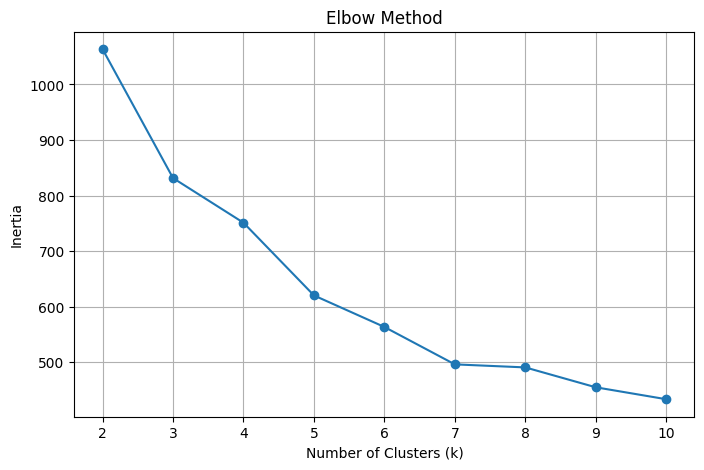

In [13]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

## K-Means Clustering

K-Means is applied with 3 clusters based on the elbow analysis.

In [14]:
# K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

df[['country', 'KMeans_Cluster']].head()

,country,KMeans_Cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,0
3,Angola,2
4,Antigua and Barbuda,0


In [15]:
# Silhouette Score

silhouette_avg = silhouette_score(X_scaled, kmeans_labels)

print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.2856


## DBSCAN Clustering

DBSCAN is used to identify clusters based on density.

In [16]:
# Apply DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("Unique DBSCAN Clusters:")
print(np.unique(dbscan_labels))

Unique DBSCAN Clusters:
[-1  0]


In [17]:
# Number of points in each cluster

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


## PCA Visualization

PCA is used to visualize clusters in two dimensions.

In [18]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df['Cluster'] = kmeans_labels

pca_df.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,2
1,0.429911,-0.588156,0
2,-0.285225,-0.455174,0
3,-2.932423,1.695555,2
4,1.033576,0.136659,0


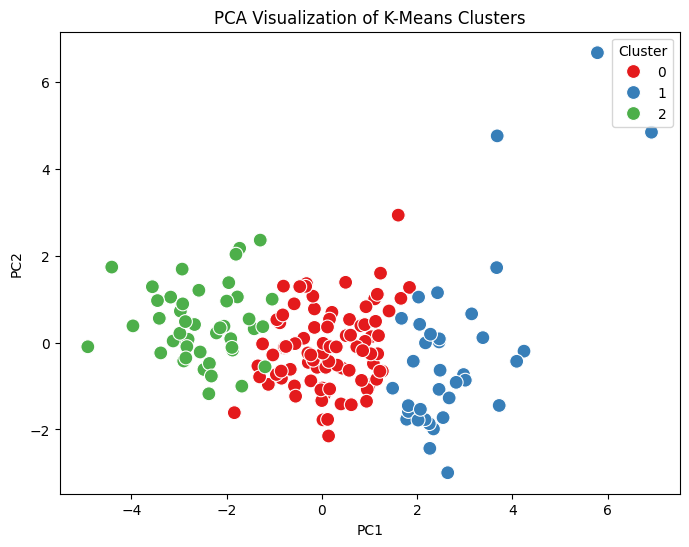

In [19]:
# PCA Scatter Plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("PCA Visualization of K-Means Clusters")
plt.show()

## Cluster Analysis

The characteristics of each cluster are analyzed using average feature values.

In [20]:
# Cluster-wise averages

cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333


## Observations

### Cluster 0
- Medium child mortality and moderate income levels.
- Represents developing countries.

### Cluster 1
- Lowest child mortality and highest income levels.
- Represents highly developed countries.

### Cluster 2
- Highest child mortality and lowest income levels.
- Represents less developed countries with greater socio-economic challenges.

### Overall Findings
- Cluster 1 shows strong economic and health indicators.
- Cluster 2 shows lower development and higher mortality rates.
- Cluster 0 lies between the other two clusters and represents developing nations.

## Sample Countries in Each Cluster

In [21]:
for cluster in sorted(df['KMeans_Cluster'].unique()):
    print(f"\nCluster {cluster}")
    print(df[df['KMeans_Cluster'] == cluster]['country'].head(10).tolist())


Cluster 0
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']

Cluster 1
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']

Cluster 2
['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.']


## Random Forest Classification

Random Forest is used to predict the cluster labels generated by K-Means.

In [22]:
# Features and target

X_rf = X
y_rf = df['KMeans_Cluster']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

# Train model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions

rf_pred = rf_model.predict(X_test)

In [23]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall:", recall_score(y_test, rf_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


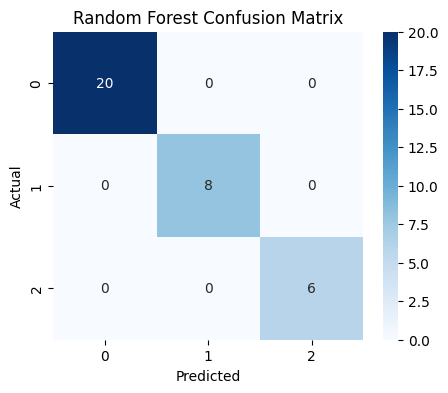

In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost Classification

XGBoost is used to predict the cluster labels generated by K-Means.

In [25]:
# Import XGBoost

from xgboost import XGBClassifier

# Create model

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# Train model

xgb_model.fit(X_train, y_train)

# Predictions

xgb_pred = xgb_model.predict(X_test)

In [26]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average='weighted'))
print("Recall:", recall_score(y_test, xgb_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, xgb_pred, average='weighted'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


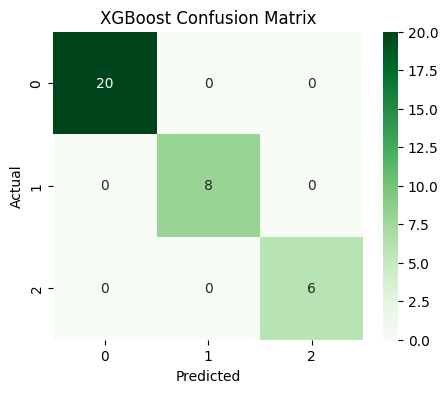

In [27]:
# Confusion Matrix

cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison

The performance of Random Forest and XGBoost models is compared using classification metrics.

In [28]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred, average='weighted'),
        precision_score(y_test, xgb_pred, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, rf_pred, average='weighted'),
        recall_score(y_test, xgb_pred, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, rf_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted')
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.0,1.0,1.0,1.0
1,XGBoost,1.0,1.0,1.0,1.0


## Feature Importance

Feature importance helps identify which factors contribute most to country segmentation.

In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,child_mort,0.293845
8,gdpp,0.210125
4,income,0.177148
7,total_fer,0.142312
6,life_expec,0.122588
2,health,0.019921
1,exports,0.014917
5,inflation,0.011745
3,imports,0.007400


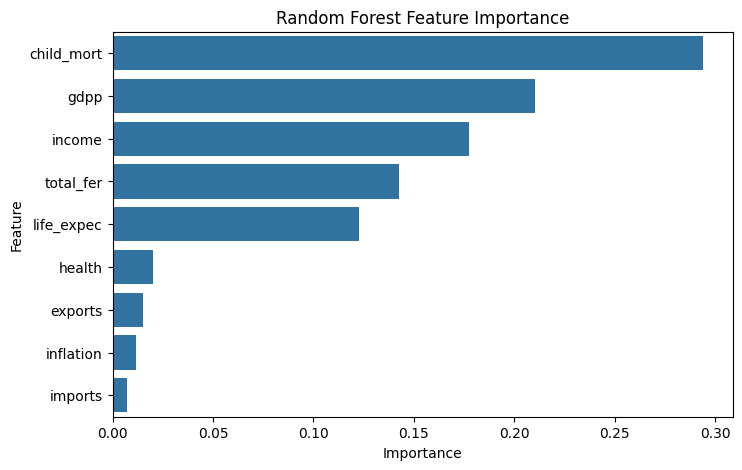

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.show()

### Observation

- Income, child mortality, and life expectancy are among the most influential features.
- These indicators play a major role in distinguishing country clusters.

## Conclusion

- Countries were successfully segmented using clustering techniques.
- PCA helped visualize the cluster structure.
- Random Forest and XGBoost accurately predicted cluster labels.
- Child mortality, GDP per capita, and income were the key factors influencing segmentation.